# PCA of ReachGrasp action trajectories

This notebook asks whether repeated actions occupy distinct regions of joint-trajectory space. Each PCA sample is one movement repetition. Every repetition is interpolated to the same 0–100% movement phase, then its arm and hand joint angles are flattened into one feature vector.

PCA is unsupervised: action and subject labels are used only after fitting, for interpretation. Phase normalization removes duration differences but preserves joint-angle magnitudes. Because all features are angles in degrees, the analysis centers each feature without variance-scaling it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse.linalg import svds

from reachgrasp.data_loading import (
    get_arm_joints, get_available_subjects, get_available_tasks, get_hand_joints,
    load_joint_angles_with_labels,
)
from reachgrasp.preprocessing import resample_signal

DATASET_ROOT = Path(".")
EXCLUDED_SUBJECTS = {}#{"sub-06", "sub-09", "sub-04", "sub-07"} #{"sub-03", "sub-06", "sub-08", "sub-10"}
PHASE_SAMPLES = 100
N_COMPONENTS = 10
EXCLUDED_RECORDINGS = {("sub-09", "HC")}  # RPinky_X contains non-finite values

## Load and phase-normalize every repetition

The dataset's own loader applies the anatomical Vicon labels and the movement boundaries from `timeCuts.json`. Subject and recording exclusions are declared above; the loader raises on any other invalid recording.

In [2]:
joint_names = get_arm_joints() + get_hand_joints()
trajectories = []
metadata = []

subjects = [subject for subject in get_available_subjects(DATASET_ROOT) if subject not in EXCLUDED_SUBJECTS]
for subject in subjects:
    for action in get_available_tasks(subject, modality="motion", base_path=DATASET_ROOT):
        if (subject, action) in EXCLUDED_RECORDINGS:
            continue
        repetitions = load_joint_angles_with_labels(subject, action, base_path=DATASET_ROOT, verbose=False)
        for repetition, (time, joint_angles) in enumerate(repetitions):
            phase_time = np.linspace(time[0], time[-1], PHASE_SAMPLES)
            phase_angles = resample_signal(time, joint_angles[joint_names], phase_time)
            trajectories.append(phase_angles.to_numpy().ravel())
            metadata.append({"subject": subject, "action": action, "repetition": repetition,
                             "duration_s": time[-1] - time[0]})

X = np.stack(trajectories)
sample_info = pd.DataFrame(metadata)
print(f"Samples: {X.shape[0]:,}")
print(f"Actions: {sample_info['action'].nunique()}")
print(f"Subjects: {sample_info['subject'].nunique()}")
print(f"Feature shape: {PHASE_SAMPLES} phases × {len(joint_names)} joints = {X.shape[1]:,}")

Samples: 1,434
Actions: 16
Subjects: 10
Feature shape: 100 phases × 31 joints = 3,100


## Fit PCA

The fit sees only the centered trajectory matrix, not the action labels. The truncated SVD computes the first ten components directly; explained variance is measured against the total centered variance, so the percentages retain their usual PCA meaning.

First 3 PCs: 81.0%
First 10 PCs: 94.1%


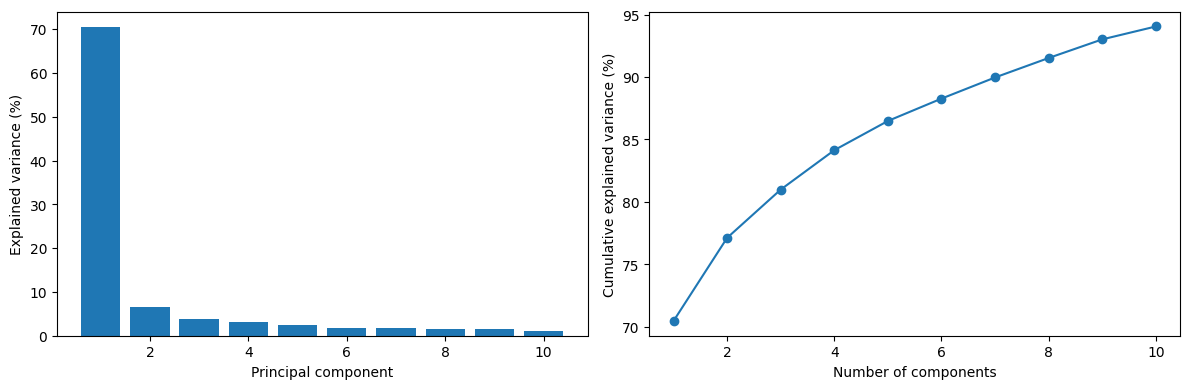

In [3]:
X_centered = X - X.mean(axis=0)
_, singular_values, components = svds(X_centered, k=N_COMPONENTS)
order = np.argsort(singular_values)[::-1]
singular_values = singular_values[order]
components = components[order]
scores = X_centered @ components.T
explained_variance_ratio = singular_values**2 / np.square(X_centered).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(np.arange(1, N_COMPONENTS + 1), 100 * explained_variance_ratio)
axes[0].set(xlabel="Principal component", ylabel="Explained variance (%)")
axes[1].plot(np.arange(1, N_COMPONENTS + 1), 100 * explained_variance_ratio.cumsum(), marker="o")
axes[1].set(xlabel="Number of components", ylabel="Cumulative explained variance (%)")
fig.tight_layout()
print(f"First 3 PCs: {100 * explained_variance_ratio[:3].sum():.1f}%")
print(f"First {N_COMPONENTS} PCs: {100 * explained_variance_ratio.sum():.1f}%")

## Are the leading components associated with action or subject?

The same PCA scores are shown twice. Compact action-specific clouds indicate action structure; compact subject-specific clouds indicate that anatomical or calibration differences dominate instead. The labelled markers are group centroids, not additional samples.

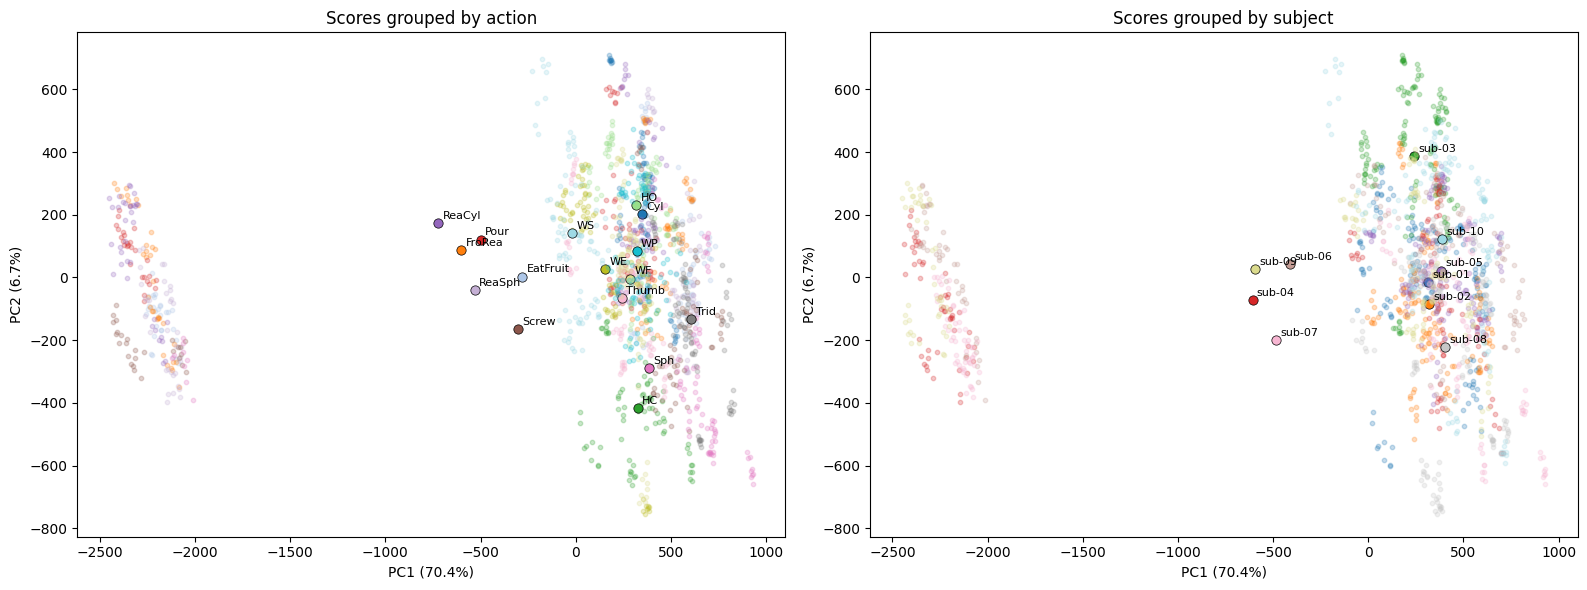

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label in zip(axes, ["action", "subject"]):
    groups = sorted(sample_info[label].unique())
    colors = plt.colormaps["tab20"](np.linspace(0, 1, len(groups)))
    for group, color in zip(groups, colors):
        selected = sample_info[label].eq(group).to_numpy()
        ax.scatter(scores[selected, 0], scores[selected, 1], s=10, alpha=0.25, color=color)
        centroid = scores[selected, :2].mean(axis=0)
        ax.scatter(*centroid, s=45, color=color, edgecolor="black", linewidth=0.5)
        ax.annotate(group, centroid, fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set(title=f"Scores grouped by {label}",
           xlabel=f"PC1 ({100 * explained_variance_ratio[0]:.1f}%)",
           ylabel=f"PC2 ({100 * explained_variance_ratio[1]:.1f}%)")
fig.tight_layout()

RBF gamma: 1.09e-06


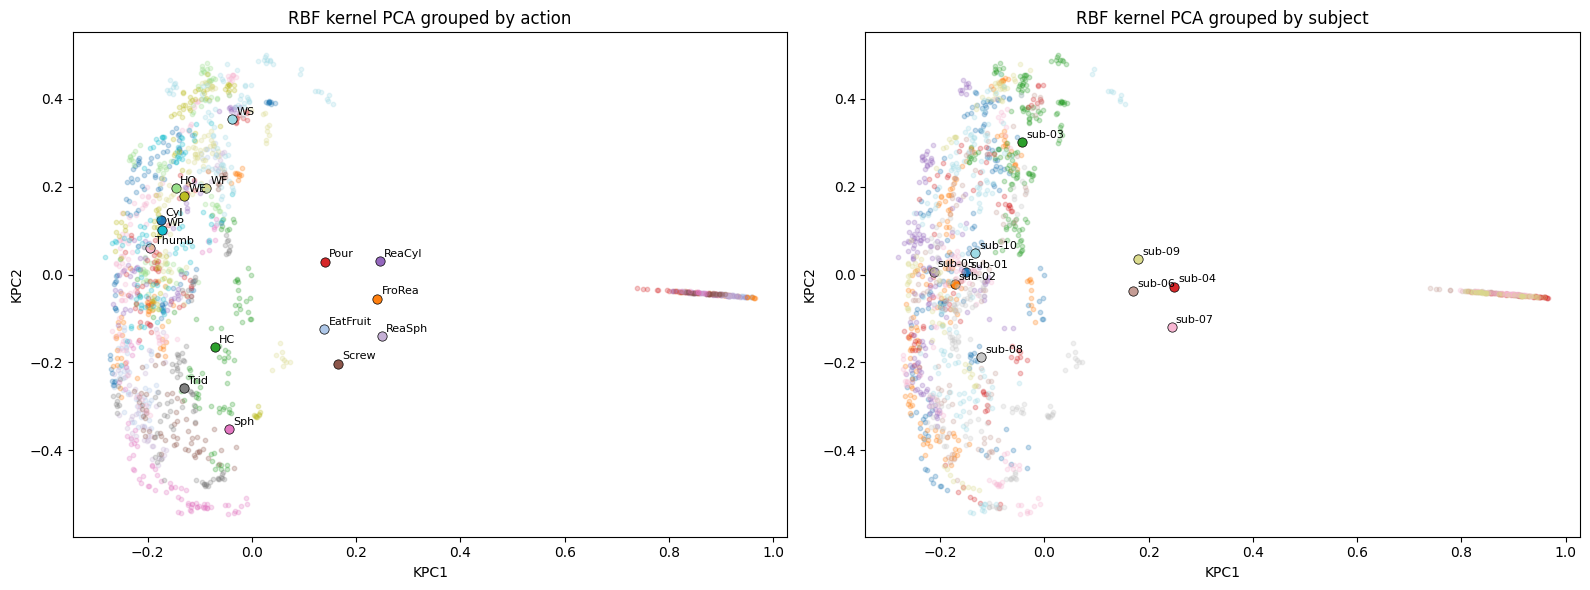

In [5]:
# RBF kernel PCA: a nonlinear view using the median pairwise-distance bandwidth.
from scipy.linalg import eigh
from scipy.spatial.distance import pdist, squareform

squared_distances = squareform(pdist(X, metric="sqeuclidean"))
gamma = 1 / np.median(squared_distances[np.triu_indices_from(squared_distances, k=1)])
kernel = np.exp(-gamma * squared_distances)
kernel_centered = kernel - kernel.mean(axis=0) - kernel.mean(axis=1)[:, None] + kernel.mean()
kernel_eigenvalues, kernel_eigenvectors = eigh(
    kernel_centered, subset_by_index=[len(kernel_centered) - 3, len(kernel_centered) - 1])
kernel_order = np.argsort(kernel_eigenvalues)[::-1]
kernel_scores = kernel_eigenvectors[:, kernel_order] * np.sqrt(kernel_eigenvalues[kernel_order])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label in zip(axes, ["action", "subject"]):
    groups = sorted(sample_info[label].unique())
    colors = plt.colormaps["tab20"](np.linspace(0, 1, len(groups)))
    for group, color in zip(groups, colors):
        selected = sample_info[label].eq(group).to_numpy()
        ax.scatter(kernel_scores[selected, 0], kernel_scores[selected, 1], s=10, alpha=0.25, color=color)
        centroid = kernel_scores[selected, :2].mean(axis=0)
        ax.scatter(*centroid, s=45, color=color, edgecolor="black", linewidth=0.5)
        ax.annotate(group, centroid, fontsize=8, xytext=(3, 3), textcoords="offset points")
    ax.set(title=f"RBF kernel PCA grouped by {label}", xlabel="KPC1", ylabel="KPC2")
fig.tight_layout()
print(f"RBF gamma: {gamma:.3g}")

Selected kernel: Linear


,mean,std
kernel,,
Linear,0.718304,0.073473
RBF 0.0625×γ₀,0.706927,0.097880
RBF 0.25×γ₀,0.687523,0.106548
RBF 1×γ₀,0.659630,0.131484
Polynomial degree 2,0.658056,0.105317
RBF 4×γ₀,0.616337,0.140064
Polynomial degree 3,0.389491,0.135472
RBF 16×γ₀,0.102454,0.048128


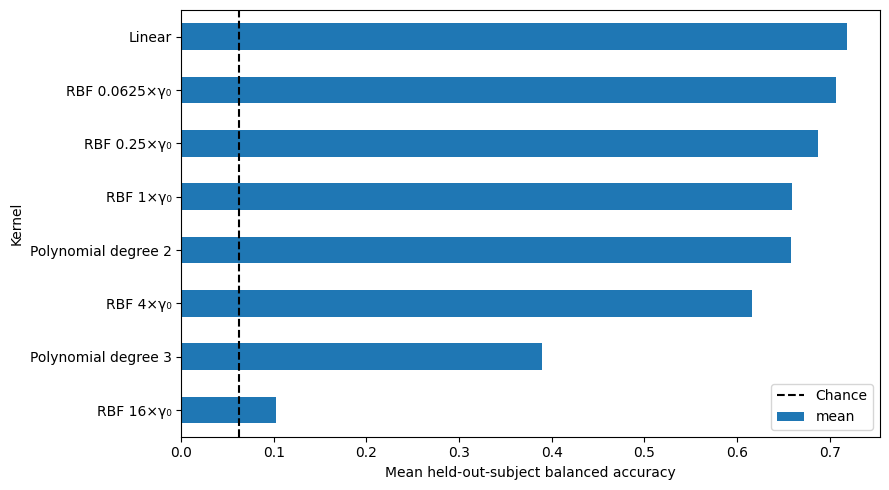

In [6]:
# Select a kernel by held-out-subject action separation in the first 10 kernel PCs.
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

kernel_cv_records = []
subject_labels = sample_info["subject"].to_numpy()
action_labels = sample_info["action"].to_numpy()
for held_out_subject in sorted(sample_info["subject"].unique()):
    test = subject_labels == held_out_subject
    train_trajectories = X[~test]
    test_trajectories = X[test]
    fold_mean = train_trajectories.mean(axis=0)
    train_trajectories = train_trajectories - fold_mean
    test_trajectories = test_trajectories - fold_mean

    train_dot = train_trajectories @ train_trajectories.T
    test_dot = test_trajectories @ train_trajectories.T
    train_norm = np.square(train_trajectories).sum(axis=1)
    test_norm = np.square(test_trajectories).sum(axis=1)
    train_distances = train_norm[:, None] + train_norm[None, :] - 2 * train_dot
    test_distances = test_norm[:, None] + train_norm[None, :] - 2 * test_dot
    np.maximum(train_distances, 0, out=train_distances)
    np.maximum(test_distances, 0, out=test_distances)
    fold_gamma = 1 / np.median(train_distances[np.triu_indices_from(train_distances, k=1)])

    kernels = {"Linear": (train_dot, test_dot)}
    for multiplier in [1 / 16, 1 / 4, 1, 4, 16]:
        name = f"RBF {multiplier:g}×γ₀"
        kernels[name] = (np.exp(-multiplier * fold_gamma * train_distances),
                         np.exp(-multiplier * fold_gamma * test_distances))
    for degree in [2, 3]:
        kernels[f"Polynomial degree {degree}"] = (
            (fold_gamma * train_dot + 1) ** degree, (fold_gamma * test_dot + 1) ** degree)

    for kernel_name, (train_kernel, test_kernel) in kernels.items():
        kernel_pca = KernelPCA(n_components=N_COMPONENTS, kernel="precomputed",
                               eigen_solver="arpack", random_state=42)
        train_scores = kernel_pca.fit_transform(train_kernel)
        test_scores = kernel_pca.transform(test_kernel)
        classifier = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
        classifier.fit(train_scores, action_labels[~test])
        accuracy = balanced_accuracy_score(action_labels[test], classifier.predict(test_scores))
        kernel_cv_records.append({"kernel": kernel_name, "held_out_subject": held_out_subject,
                                  "balanced_accuracy": accuracy})

kernel_cv_scores = pd.DataFrame(kernel_cv_records)
kernel_cv_summary = kernel_cv_scores.groupby("kernel")["balanced_accuracy"].agg(["mean", "std"])
kernel_cv_summary = kernel_cv_summary.sort_values("mean", ascending=False)
ax = kernel_cv_summary.sort_values("mean")["mean"].plot.barh(figsize=(9, 5))
ax.axvline(1 / sample_info["action"].nunique(), color="black", linestyle="--", label="Chance")
ax.set(xlabel="Mean held-out-subject balanced accuracy", ylabel="Kernel")
ax.legend()
plt.tight_layout()
print(f"Selected kernel: {kernel_cv_summary.index[0]}")
kernel_cv_summary

## Which joints contribute to each component?

Each component is reshaped back into movement phase × joint. The root-mean-square loading across phase summarizes a joint's overall contribution. This is descriptive: a large loading does not establish that the joint causes action separation.

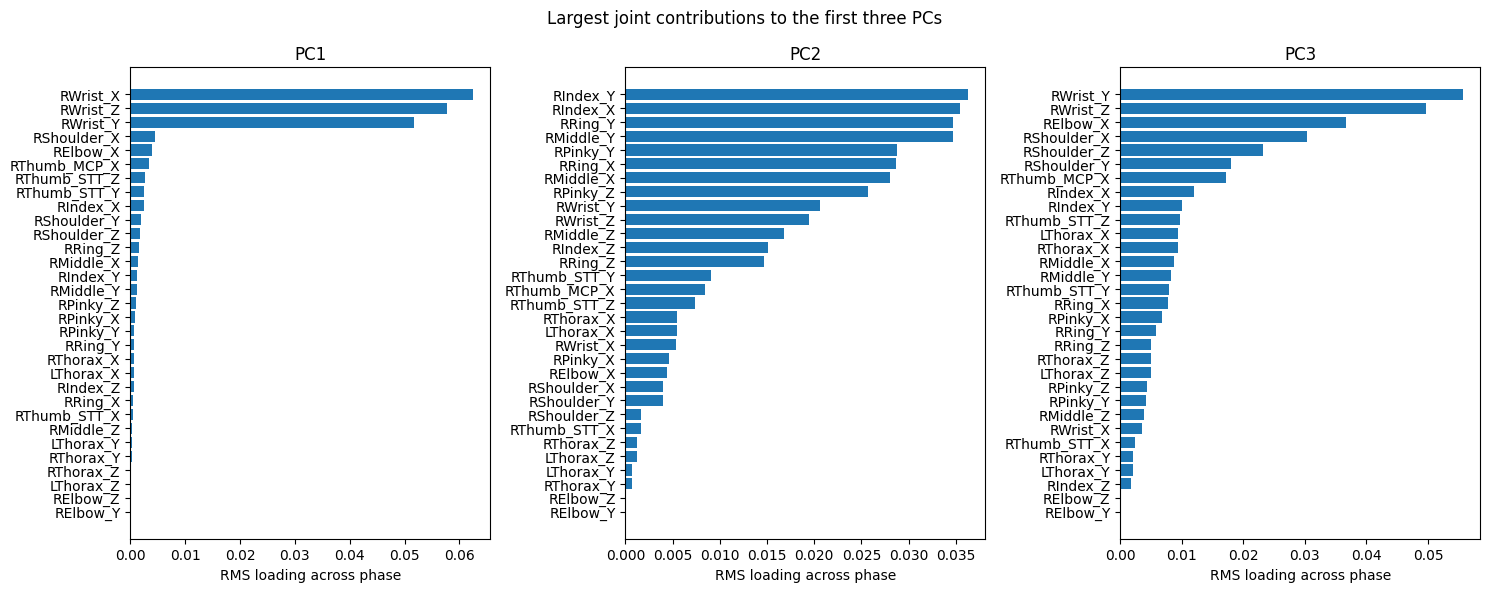

In [7]:
joint_contributions = np.sqrt(np.mean(components[:3].reshape(3, PHASE_SAMPLES, len(joint_names))**2, axis=1))
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for component_index, ax in enumerate(axes):
    top = np.argsort(joint_contributions[component_index])# [-12:]
    ax.barh(np.asarray(joint_names)[top], joint_contributions[component_index, top])
    ax.set(title=f"PC{component_index + 1}", xlabel="RMS loading across phase")
fig.suptitle("Largest joint contributions to the first three PCs")
fig.tight_layout()